# Team Negotiation

One negotiating party is replaced by a private **team of three open-weight models**
that, on every turn, **draft** a move independently, **discuss** it for two rounds,
and select a single move by **Borda vote** before replying to the opponent. The
opponent is always an ordinary single agent. Two compositions are studied on the
**small tier (12–14B: Gemma-3-12B-IT, Ministral-3-14B, Qwen3-14B)**:

- **Homogeneous** — three copies of one model, played against a single agent of the
  same model.
- **Heterogeneous** — one Gemma, one Ministral and one Qwen, played against each
  single model in turn.

### Baseline (matched per team type)

The team's opponent is itself a single agent, so the head-to-head win rate already
compares a team to a single agent. To control for opponent strength and seat we also
match each team cell to a single agent **in the same seat against the same opponent**:

- **Homogeneous team of model $M$** vs the **same-model self-play** baseline
  ($M$ vs $M$, default×default) — holds model, opponent and seat fixed, so only
  team-vs-single differs. This is the cleanest deliberation A/B.
- **Heterogeneous team** vs the **pool of single agents facing the same opponent** in
  the same seat (the two cross-play opponents plus the opponent's own self-play).

All baselines are taken at `max_retries=0`, matching the team's condition. The
homogeneous baseline shares the opponent's model by construction, a confound we return
to when comparing compositions.

In [1]:
import sys, os, json, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


def find_repo_root():
    starts = [Path.cwd()]
    if "__file__" in globals():
        starts.append(Path(__file__).resolve().parent)
    for start in starts:
        for c in (start, *start.parents):
            if (c / ".logs").exists() and (c / "configs").exists() and (c / "_notebooks").exists():
                return c
    raise FileNotFoundError("repo root not found")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
warnings.filterwarnings("ignore")

import seaborn as sns
import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci

# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

LOGS_ROOT = str(ROOT_DIR / ".logs")
SIZE = "small"
NOTEBOOK_NAME = "4_team_negotiation"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    # Save without a whole-figure title; the LaTeX caption supplies it.
    sup = getattr(fig, "_suptitle", None)
    hidden = []
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    fig.savefig(FIG_DIR / f"{slug}.png", dpi=300, bbox_inches="tight")
    for a in hidden:
        a.set_visible(True)


GAMES = ["trading", "ultimatum", "buysell"]
GAME_LABEL = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}
FAMILIES = ["gemma", "qwen", "ministral"]
FAM_LABEL = {"gemma": "Gemma", "qwen": "Qwen", "ministral": "Mistral"}
PAYOFF_BOUNDS = {"trading": (-30, 30), "ultimatum": (0, 100), "buysell": (-40, 60)}

# Comparison palette aligned with the other OSS notebooks.
COL_SINGLE = "#0173b2"                               # blue
COL_HOMO = style.STRATEGY_COLORS["Team (homo)"]      # orange
COL_HETERO = style.STRATEGY_COLORS["Team (hetero)"]  # green
SEAT_COLORS = {"P1": "#0173b2", "P2": "#de8f05"}
GAME_COLORS = {"trading": "#0173b2", "ultimatum": "#de8f05", "buysell": "#029e73"}
FAM_COLORS = {f: style.FAMILY_COLORS[f] for f in FAMILIES}
VAR_MARKER = {"homo": "o", "hetero": "^"}


In [2]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for s in ("-Instruct", "-instruct"):
        name = name.replace(s, "")
    return name


def resource_value(res):
    return sum(res["_value"].values())


def model_family(name):
    n = name.lower()
    for fam in FAMILIES:
        if fam in n:
            return fam
    return "ministral" if "mistral" in n else n


def _load_run(path, game):
    # Per-game payoff + validity. ONE function for every source (team and baselines)
    # so team and baseline payoffs are always computed identically.
    with open(path) as f:
        data = json.load(f)
    states, players = data["game_state"], data["players"]
    last = states[-1]
    completed = last.get("current_iteration") == "END"
    out = dict(
        m1=clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        m2=clean_name(players[1].get("model_id", players[1].get("model", "?"))),
        cls1=players[0].get("class"), cls2=players[1].get("class"),
        completed=completed, payoff_1=np.nan, payoff_2=np.nan, deal=False,
    )
    if not completed:
        return out
    s = last.get("summary")
    if s is None:
        out["completed"] = False
        return out
    deal = str(s.get("final_response")) == "ACCEPT"
    if game == "trading":
        ini, fin = s["initial_resources"], s["final_resources"]
        p1 = resource_value(fin[0]) - resource_value(ini[0])
        p2 = resource_value(fin[1]) - resource_value(ini[1])
    elif game == "ultimatum":
        p1 = resource_value(s["player_outcome"][0])
        p2 = resource_value(s["player_outcome"][1])
    else:  # buysell -> player_outcome is [seller, buyer] surplus
        o1, o2 = s["player_outcome"]
        try:
            p1, p2 = float(o1), float(o2)
        except (TypeError, ValueError):
            p1 = p2 = np.nan
    if not deal:
        p1 = p2 = 0.0
    out.update(payoff_1=p1, payoff_2=p2, deal=deal)
    return out


def payoff_valid(game, p1, p2):
    lo, hi = PAYOFF_BOUNDS[game]
    return bool(np.isfinite(p1) and np.isfinite(p2) and lo <= p1 <= hi and lo <= p2 <= hi)


def norm_payoff(game, p):
    # payoff rescaled to its game's [0, 1] span (PAYOFF_BOUNDS) for cross-game pooling.
    lo, hi = PAYOFF_BOUNDS[game]
    return (p - lo) / (hi - lo)


def focal_view(seat, game, r):
    # (focal_payoff, opp_payoff, valid, win); win is NaN on tie / invalid / incomplete.
    if not r["completed"]:
        return np.nan, np.nan, False, np.nan
    p1, p2 = r["payoff_1"], r["payoff_2"]
    valid = payoff_valid(game, p1, p2)
    fp, op = (p1, p2) if seat == "P1" else (p2, p1)
    if not valid or not np.isfinite(fp):
        win = np.nan
    elif fp > op:
        win = 1.0
    elif fp < op:
        win = 0.0
    else:
        win = np.nan
    return fp, op, valid, win

In [3]:
def _states(root):
    return glob.glob(os.path.join(root, "**", "game_state.json"), recursive=True)


def _parse_p1(folder):       # team_{members}_vs_{opp}
    for part in folder.split(os.sep):
        if part.startswith("team_") and "_vs_" in part:
            team_raw, opp_raw = part[len("team_"):].rsplit("_vs_", 1)
            return team_raw, opp_raw
    return None, None


def _parse_p2(folder):       # {opp}_vs_team_{members}
    for part in folder.split(os.sep):
        if "_vs_team_" in part:
            opp_raw, team_raw = part.split("_vs_team_", 1)
            return team_raw, opp_raw
    return None, None


rows = []
# Team rows, both seats (P1 = *_v1, P2 = *_v1_p2).
for game in GAMES:
    for variant in ("homo", "hetero"):
        for seat, suffix, parser in (("P1", "", _parse_p1), ("P2", "_p2", _parse_p2)):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for path in _states(root):
                team_raw, opp_raw = parser(os.path.dirname(path))
                if opp_raw is None:
                    continue
                r = _load_run(path, game)
                fp, op, valid, win = focal_view(seat, game, r)
                base = "trio" if variant == "hetero" else model_family(clean_name(team_raw.split("_x3")[0]))
                rows.append(dict(source="team", game=game, strategy=f"Team ({variant})",
                                 variant=variant, team_base=base,
                                 opponent=model_family(clean_name(opp_raw)), seat=seat,
                                 focal_payoff=fp, opp_payoff=op, completed=r["completed"],
                                 valid=valid, win=win))


def _add_baseline(game, root, kind, cond=None):
    for path in _states(root):
        if cond and cond not in path:
            continue
        r = _load_run(path, game)
        for seat in ("P1", "P2"):
            fp, op, valid, win = focal_view(seat, game, r)
            fm = r["m1"] if seat == "P1" else r["m2"]
            om = r["m2"] if seat == "P1" else r["m1"]
            rows.append(dict(source="baseline", game=game, strategy="Single",
                             variant=None, team_base=None,
                             focal_model=model_family(fm), opponent=model_family(om), seat=seat,
                             focal_payoff=fp, opp_payoff=op, completed=r["completed"],
                             valid=valid, win=win, baseline_kind=kind))


for game in GAMES:
    _add_baseline(game, os.path.join(LOGS_ROOT, "section_one", f"{game}_section_one", "no_retries", SIZE),
                  "crossplay")
    _add_baseline(game, os.path.join(LOGS_ROOT, "self_refine", f"{game}_self_refine_v1", SIZE),
                  "selfplay", cond="defaultP1_defaultP2")

DF = pd.DataFrame(rows)
DF["game"] = pd.Categorical(DF["game"], categories=GAMES, ordered=True)
TEAM = DF[DF.source == "team"].copy()
BASE = DF[DF.source == "baseline"].copy()

print("Team runs per game x variant x seat (30 per matchup, 3 matchups -> 90):")
print(TEAM.groupby(["game", "variant", "seat"]).size().unstack("seat"))
print("\nBaseline runs (long, one row per seat) per game x kind:")
print(BASE.groupby(["game", "baseline_kind"]).size().unstack("baseline_kind"))

Team runs per game x variant x seat (30 per matchup, 3 matchups -> 90):
seat               P1  P2
game      variant        
trading   hetero   90  90
          homo     90  90
ultimatum hetero   90  90
          homo     90  90
buysell   hetero   90  90
          homo     90  90

Baseline runs (long, one row per seat) per game x kind:
baseline_kind  crossplay  selfplay
game                              
trading              360       180
ultimatum            360       180
buysell              360       180


In [4]:
def wr_ci(s):
    # ties-excluded win rate + Wilson 95% interval + decisive-game count.
    w = s.dropna()
    k, n = int((w == 1).sum()), len(w)
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    return rate, lo, hi, n



def comp_ci(s):
    # completion rate + Wilson 95% interval over a boolean completed series.
    b = s.dropna()
    k, n = int(b.sum()), len(b)
    rate = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    return rate, lo, hi


def mean_payoff_ci(s):
    x = s.dropna().values
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    lo, hi = bootstrap_ci(x)
    return float(np.mean(x)), lo, hi


def mean_diff_ci(a, b, n_boot=4000, seed=17):
    # Independent bootstrap interval for team-minus-single mean payoff.
    x, y = a.dropna().values, b.dropna().values
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan, np.nan
    diff = float(np.mean(x) - np.mean(y))
    if len(x) < 2 or len(y) < 2:
        return diff, np.nan, np.nan
    rng = np.random.default_rng(seed + len(x) * 101 + len(y))
    xb = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    yb = rng.choice(y, size=(n_boot, len(y)), replace=True).mean(axis=1)
    lo, hi = np.percentile(xb - yb, [2.5, 97.5])
    return diff, float(lo), float(hi)


def matched_single(game, seat, variant, opponent):
    if variant == "homo":          # same-model self-play, same seat
        return BASE[(BASE.game == game) & (BASE.seat == seat) & (BASE.baseline_kind == "selfplay")
                    & (BASE.focal_model == opponent) & (BASE.opponent == opponent)]
    return BASE[(BASE.game == game) & (BASE.seat == seat) & (BASE.opponent == opponent)]


# 36 matched team-vs-single cells (game x seat x variant x opponent).
recs = []
for game in GAMES:
    for seat in ("P1", "P2"):
        for variant in ("homo", "hetero"):
            tt = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == variant)]
            for opp in sorted(tt["opponent"].unique()):
                ts = tt[tt.opponent == opp]
                bs = matched_single(game, seat, variant, opp)
                tr, tlo, thi, tn = wr_ci(ts["win"])
                br, blo, bhi, bn = wr_ci(bs["win"])
                team_pay = ts.loc[ts.valid, "focal_payoff"]
                single_pay = bs.loc[bs.valid, "focal_payoff"]
                tp, _, _ = mean_payoff_ci(team_pay)
                bp, _, _ = mean_payoff_ci(single_pay)
                pdiff, plo, phi = mean_diff_ci(team_pay, single_pay)
                rel = "team>single" if tlo > bhi else "team<single" if thi < blo else "overlap"
                pay_rel = "team>single" if plo > 0 else "team<single" if phi < 0 else "overlap"
                recs.append(dict(game=game, seat=seat, variant=variant, opponent=opp,
                                 team_wr=tr, single_wr=br, team_pay=tp, single_pay=bp,
                                 pay_diff=pdiff, pay_lo=plo, pay_hi=phi,
                                 tn=tn, bn=bn, rel=rel, pay_rel=pay_rel))
CMP = pd.DataFrame(recs)

# 18 homogeneous-vs-heterogeneous cells against a common opponent + seat.
hh = []
for game in GAMES:
    for seat in ("P1", "P2"):
        for opp in FAMILIES:
            ho = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == "homo") & (TEAM.opponent == opp)]
            he = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == "hetero") & (TEAM.opponent == opp)]
            hr, hlo, hhi, hn = wr_ci(ho["win"])
            er, elo, ehi, en = wr_ci(he["win"])
            rel = "overlap"
            if hn and en:
                rel = "homo>hetero" if hlo > ehi else "hetero>homo" if elo > hhi else "overlap"
            hh.append(dict(game=game, seat=seat, opponent=opp, homo_wr=hr, hetero_wr=er,
                           hn=hn, en=en, rel=rel))
HH = pd.DataFrame(hh)

print("Team-vs-single matched cells (win-rate CI relationship):")
print(CMP["rel"].value_counts().to_string())
print("\nTeam-vs-single matched cells (payoff-difference bootstrap relationship):")
print(CMP["pay_rel"].value_counts().to_string())
print(f"\nmean(team - single) win rate = {(CMP.team_wr - CMP.single_wr).mean():+.3f}")
print(f"mean(team - single) payoff   = {CMP.pay_diff.mean():+.3f}")
print("\nHomo-vs-hetero common-opponent cells:")
print(HH["rel"].value_counts().to_string())
print(f"mean(hetero - homo) win rate = {(HH.hetero_wr - HH.homo_wr).mean():+.3f}")


Team-vs-single matched cells (win-rate CI relationship):
rel
overlap    36

Team-vs-single matched cells (payoff-difference bootstrap relationship):
pay_rel
overlap        27
team>single     9

mean(team - single) win rate = +0.037
mean(team - single) payoff   = +2.453

Homo-vs-hetero common-opponent cells:
rel
overlap        17
homo>hetero     1
mean(hetero - homo) win rate = -0.005




Before fixing on any structure, a first look at win rates against the single agent,
the gap between compositions, and where games fall apart.

In [5]:
# Head-to-head: team win rate against its single-agent opponent, by game x seat x variant.
ht = (TEAM.groupby(["game", "seat", "variant"])
      .apply(lambda d: pd.Series(dict(zip(["win_rate", "lo", "hi", "n"], wr_ci(d["win"])))))
      .reset_index())
print("Head-to-head team win rate (ties excluded):")
print(ht.assign(win_rate=ht.win_rate.round(2), lo=ht.lo.round(2), hi=ht.hi.round(2),
                n=ht.n.astype(int)).to_string(index=False))

print("\nCompletion rate (max_retries = 0):")
tc = TEAM.groupby(["game", "seat"])["completed"].mean().round(3).unstack("seat")
b1 = BASE[BASE.seat == "P1"]
bc = b1.groupby(["game", "baseline_kind"])["completed"].mean().round(3).unstack("baseline_kind")
print(pd.concat([tc.add_prefix("team_"), bc.add_prefix("single_")], axis=1).to_string())

Head-to-head team win rate (ties excluded):
     game seat variant  win_rate   lo   hi  n
  trading   P1  hetero      0.30 0.21 0.41 76
  trading   P1    homo      0.31 0.21 0.43 65
  trading   P2  hetero      0.85 0.75 0.92 67
  trading   P2    homo      0.88 0.77 0.94 64
ultimatum   P1  hetero      0.93 0.84 0.97 69
ultimatum   P1    homo      0.95 0.87 0.98 65
ultimatum   P2  hetero      0.01 0.00 0.08 70
ultimatum   P2    homo      0.11 0.05 0.20 66
  buysell   P1  hetero      0.20 0.12 0.32 55
  buysell   P1    homo      0.09 0.04 0.19 64
  buysell   P2  hetero      0.96 0.88 0.99 72
  buysell   P2    homo      0.93 0.85 0.97 73

Completion rate (max_retries = 0):
           team_P1  team_P2  single_crossplay  single_selfplay
game                                                          
trading      0.889    0.944             0.956            0.856
ultimatum    0.972    0.967             1.000            0.889
buysell      0.867    0.950             1.000            0.933


### 1. Does deliberation beat a single agent?

**Against the matched single agent the team barely moves.** Each point is one of
the 36 (game × seat × composition × opponent) cells: team win rate versus the win rate
of a single agent in the same seat against the same opponent. Points on the diagonal
mean no difference.

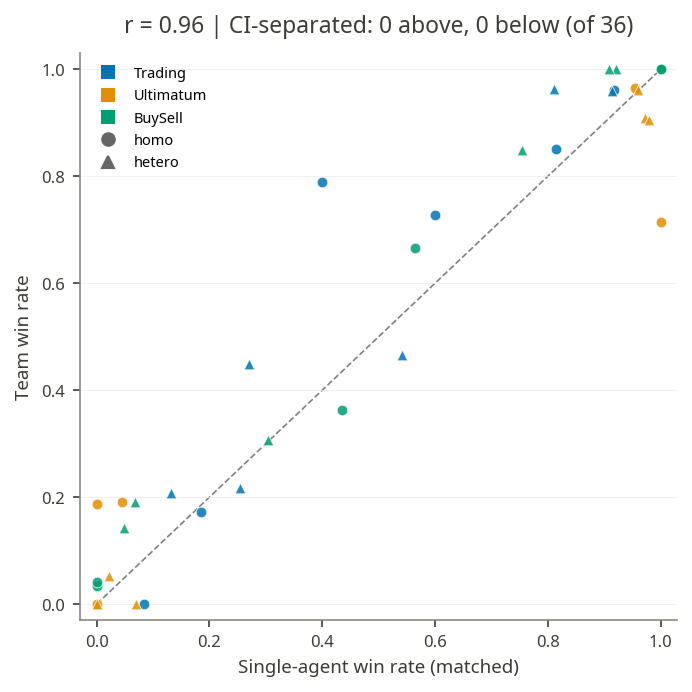

Win-rate scatter data (team vs single, matched cells):
     game seat variant  opponent  single_wr  team_wr     rel
  trading   P1    homo     gemma      0.185    0.172 overlap
  trading   P1    homo ministral      0.083    0.000 overlap
  trading   P1    homo      qwen      0.400    0.789 overlap
  trading   P1  hetero     gemma      0.269    0.448 overlap
  trading   P1  hetero ministral      0.132    0.208 overlap
  trading   P1  hetero      qwen      0.255    0.217 overlap
  trading   P2    homo     gemma      0.815    0.852 overlap
  trading   P2    homo ministral      0.917    0.962 overlap
  trading   P2    homo      qwen      0.600    0.727 overlap
  trading   P2  hetero     gemma      0.810    0.963 overlap
  trading   P2  hetero ministral      0.914    0.960 overlap
  trading   P2  hetero      qwen      0.542    0.467 overlap
ultimatum   P1    homo     gemma      1.000    1.000 overlap
ultimatum   P1    homo ministral      0.955    0.964 overlap
ultimatum   P1    homo      qw

In [6]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH * 1.5, HALF_WIDTH * 1.5))
ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
for _, r in CMP.iterrows():
    ax.scatter(r.single_wr, r.team_wr, s=26, color=GAME_COLORS[r.game],
               marker=VAR_MARKER[r.variant], alpha=0.85, edgecolor="white", linewidth=0.4)
from matplotlib.lines import Line2D
leg_game = [Line2D([], [], marker="s", ls="", color=GAME_COLORS[g], label=GAME_LABEL[g]) for g in GAMES]
leg_var = [Line2D([], [], marker=VAR_MARKER[v], ls="", color="0.4", label=v) for v in ("homo", "hetero")]
ax.legend(handles=leg_game + leg_var, loc="upper left", fontsize=7, ncols=1)
ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Single-agent win rate (matched)"); ax.set_ylabel("Team win rate")
r_pearson = CMP[["team_wr", "single_wr"]].corr().iloc[0, 1]
n_above = (CMP.rel == "team>single").sum(); n_below = (CMP.rel == "team<single").sum()
ax.set_title(f"r = {r_pearson:.2f} | CI-separated: {n_above} above, {n_below} below (of {len(CMP)})")
save_plot(fig, "team_vs_single_winrate")
plt.show()
print("Win-rate scatter data (team vs single, matched cells):")
print(CMP[["game", "seat", "variant", "opponent", "single_wr", "team_wr", "rel"]].round(3).to_string(index=False))
print(f"\nmean(team - single) win rate = {(CMP.team_wr - CMP.single_wr).mean():+.3f} "
      f"(median {(CMP.team_wr - CMP.single_wr).median():+.3f})")

The points lie on the diagonal: team win rate tracks the matched single agent
almost exactly (r ≈ 0.96). **Not one of the 36 cells shows a confidence-interval-
separated difference** in either direction. The mean lift from running three
deliberating models instead of one is +0.04 in win rate — within noise, and small
relative to the per-cell intervals. The team inherits the single agent's win rate
against each opponent rather than improving on it.

Payoff margins ask whether the team extracts more value even when win rate does not move. Mean team payoff is compared against the matched single agent, one point per cell.


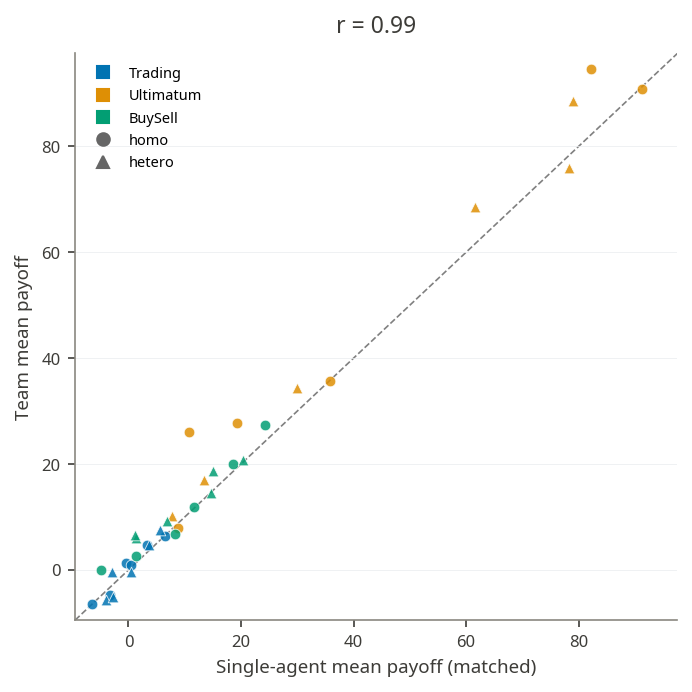

Payoff scatter data (team vs single, matched cells):
     game seat variant  opponent  single_pay  team_pay  pay_diff     pay_rel
  trading   P1    homo     gemma      -3.267    -4.733    -1.467     overlap
  trading   P1    homo ministral      -6.423    -6.474    -0.051     overlap
  trading   P1    homo      qwen      -0.476     1.367     1.843     overlap
  trading   P1  hetero     gemma      -2.867    -0.333     2.533     overlap
  trading   P1  hetero ministral      -3.988    -5.630    -1.641     overlap
  trading   P1  hetero      qwen      -2.689    -5.125    -2.436     overlap
  trading   P2    homo     gemma       3.267     4.643     1.376     overlap
  trading   P2    homo ministral       6.423     6.393    -0.030     overlap
  trading   P2    homo      qwen       0.476     0.967     0.490     overlap
  trading   P2  hetero     gemma       3.586     4.690     1.103     overlap
  trading   P2  hetero ministral       5.537     7.577     2.040     overlap
  trading   P2  hetero 

In [7]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH * 1.5, HALF_WIDTH * 1.5))
lo = min(CMP.single_pay.min(), CMP.team_pay.min()) - 3
hi = max(CMP.single_pay.max(), CMP.team_pay.max()) + 3
ax.plot([lo, hi], [lo, hi], ls="--", color="0.5", lw=0.8, zorder=0)
for _, r in CMP.iterrows():
    ax.scatter(r.single_pay, r.team_pay, s=26, color=GAME_COLORS[r.game],
               marker=VAR_MARKER[r.variant], alpha=0.85, edgecolor="white", linewidth=0.4)
ax.legend(handles=leg_game + leg_var, loc="upper left", fontsize=7)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Single-agent mean payoff (matched)"); ax.set_ylabel("Team mean payoff")
ax.set_title(f"r = {CMP[['team_pay','single_pay']].corr().iloc[0,1]:.2f}")
save_plot(fig, "team_vs_single_payoff")
plt.show()
print("Payoff scatter data (team vs single, matched cells):")
print(CMP[["game", "seat", "variant", "opponent", "single_pay", "team_pay", "pay_diff", "pay_rel"]].round(3).to_string(index=False))
print(f"\nmean(team - single) payoff = {(CMP.team_pay - CMP.single_pay).mean():+.2f}")


Payoff tracks the matched single agent closely (r ≈ 0.99), but it is not a pure null. Nine of the 36 bootstrap payoff-difference intervals favor the team and none favor the single agent. The average gain is +2.5, small against the games' ranges (Ultimatum 0–100, BuySell ±60, Trading ±30), and it does not produce any confidence-interval-separated win-rate gain. Payoff therefore shows limited local value gains, not a broad negotiating advantage.


Raw gains and losses are still worth locating per cell. The forest plots the signed
team-minus-single delta for **both** metrics across all 36 cells — win rate on the left,
and mean payoff with its percentile-bootstrap interval on the right — split by composition
(homo vs hetero) and coloured by opponent. This tests whether the pooled result hides
specific games, seats, opponents, or compositions where deliberation reliably helps or
hurts, and whether the small positive payoff edge is concentrated in one composition or
spread uniformly.

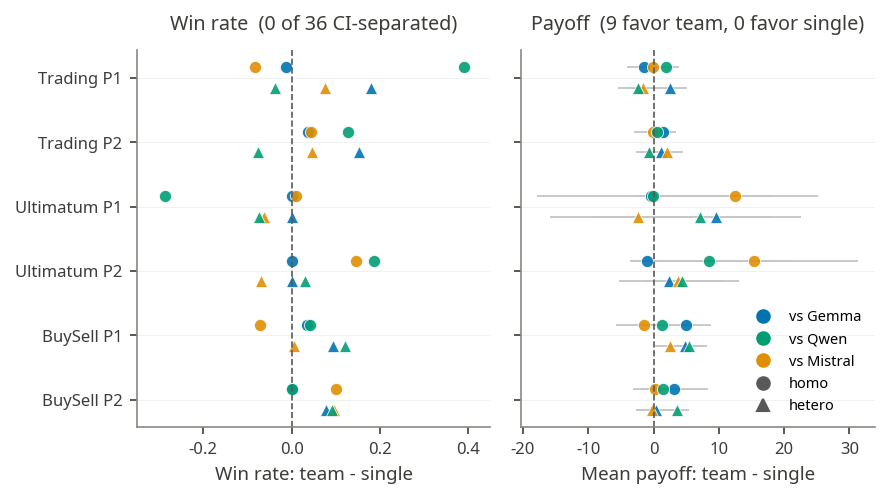

Per-cell team minus single deltas behind the two-panel figure:
     game seat variant  opponent  wr_delta  pay_diff  pay_lo  pay_hi     rel     pay_rel
  trading   P1    homo     gemma    -0.013    -1.467  -4.133   1.334 overlap     overlap
  trading   P1    homo ministral    -0.083    -0.051  -2.765   2.899 overlap     overlap
  trading   P1    homo      qwen     0.389     1.843  -0.429   3.963 overlap     overlap
  trading   P1  hetero     gemma     0.179     2.533  -0.022   5.178 overlap     overlap
  trading   P1  hetero ministral     0.076    -1.641  -4.135   0.866 overlap     overlap
  trading   P1  hetero      qwen    -0.038    -2.436  -5.449   0.603 overlap     overlap
  trading   P2    homo     gemma     0.037     1.376  -0.741   3.400 overlap     overlap
  trading   P2    homo ministral     0.045    -0.030  -3.017   2.822 overlap     overlap
  trading   P2    homo      qwen     0.127     0.490  -1.305   2.348 overlap     overlap
  trading   P2  hetero     gemma     0.153     

In [8]:
from matplotlib.lines import Line2D

CMP = CMP.assign(
    wr_delta=CMP.team_wr - CMP.single_wr,
    payoff_delta=CMP.pay_diff,
    cell=lambda d: d.game.map(GAME_LABEL) + " " + d.seat,
)
cell_order = [f"{GAME_LABEL[g]} {seat}" for g in GAMES for seat in ("P1", "P2")]
ypos = {c: i for i, c in enumerate(cell_order)}
variant_offset = {"homo": -0.16, "hetero": 0.16}

fig, (ax_wr, ax_pay) = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.4), sharey=True)

# Left: signed win-rate delta. Per-cell proportion-difference CIs are not estimated;
# the CI-separation count from the matched scatter (CMP.rel) is reported in the title.
for _, r in CMP.iterrows():
    ax_wr.scatter(r.wr_delta, ypos[r.cell] + variant_offset[r.variant],
                  s=34, marker=VAR_MARKER[r.variant], color=FAM_COLORS.get(r.opponent, "0.4"),
                  alpha=0.9, edgecolor="white", linewidth=0.4, zorder=2)
ax_wr.axvline(0, ls="--", color="0.35", lw=0.8)
ax_wr.set_xlim(-0.35, 0.45)
ax_wr.set_xlabel("Win rate: team - single")
n_sep = int((CMP.rel != "overlap").sum())
ax_wr.set_title(f"Win rate  ({n_sep} of {len(CMP)} CI-separated)", fontsize=9.5)

# Right: payoff delta with percentile-bootstrap CI; cells whose interval clears 0 stand out.
for _, r in CMP.iterrows():
    yy = ypos[r.cell] + variant_offset[r.variant]
    ax_pay.errorbar(r.pay_diff, yy, xerr=[[r.pay_diff - r.pay_lo], [r.pay_hi - r.pay_diff]],
                    fmt="none", ecolor="0.78", lw=0.9, zorder=1)
    ax_pay.scatter(r.pay_diff, yy, s=34, marker=VAR_MARKER[r.variant],
                   color=FAM_COLORS.get(r.opponent, "0.4"), alpha=0.9,
                   edgecolor="white", linewidth=0.4, zorder=2)
ax_pay.axvline(0, ls="--", color="0.35", lw=0.8)
ax_pay.set_xlabel("Mean payoff: team - single")
npos = int((CMP.pay_rel == "team>single").sum())
nneg = int((CMP.pay_rel == "team<single").sum())
ax_pay.set_title(f"Payoff  ({npos} favor team, {nneg} favor single)", fontsize=9.5)

ax_wr.set_yticks(range(len(cell_order)), cell_order)
ax_wr.invert_yaxis()
opp_handles = [Line2D([], [], marker="o", ls="", color=FAM_COLORS[f], label=f"vs {FAM_LABEL[f]}") for f in FAMILIES]
var_handles = [Line2D([], [], marker=VAR_MARKER[v], ls="", color="0.35", label=v) for v in ("homo", "hetero")]
ax_pay.legend(handles=opp_handles + var_handles, fontsize=7, loc="lower right", ncols=1)
fig.tight_layout()
save_plot(fig, "team_single_delta_cells")
plt.show()
print("Per-cell team minus single deltas behind the two-panel figure:")
print(CMP[["game", "seat", "variant", "opponent", "wr_delta", "pay_diff", "pay_lo", "pay_hi", "rel", "pay_rel"]].round(3).to_string(index=False))

cols = ["game", "seat", "variant", "opponent", "team_wr", "single_wr", "wr_delta", "tn", "bn"]
print("Largest raw win-rate disadvantages (none CI-separated):")
print(CMP.sort_values("wr_delta")[cols].head(6).round(3).to_string(index=False))
print("\nPayoff cells whose bootstrap CI excludes 0 (split by composition):")
sig = CMP[CMP.pay_rel != "overlap"].sort_values(["variant", "pay_diff"], ascending=[True, False])
print(sig[["variant", "game", "seat", "opponent", "payoff_delta", "pay_lo", "pay_hi"]].round(2).to_string(index=False))
print(f"\nmean payoff delta: homo {CMP[CMP.variant=='homo'].pay_diff.mean():+.2f} | "
      f"hetero {CMP[CMP.variant=='hetero'].pay_diff.mean():+.2f} | all {CMP.pay_diff.mean():+.2f}")


### Proposer-seat surplus

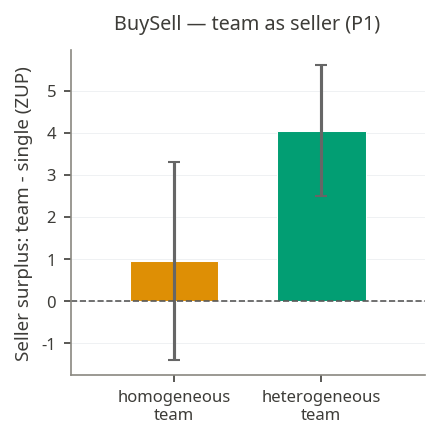

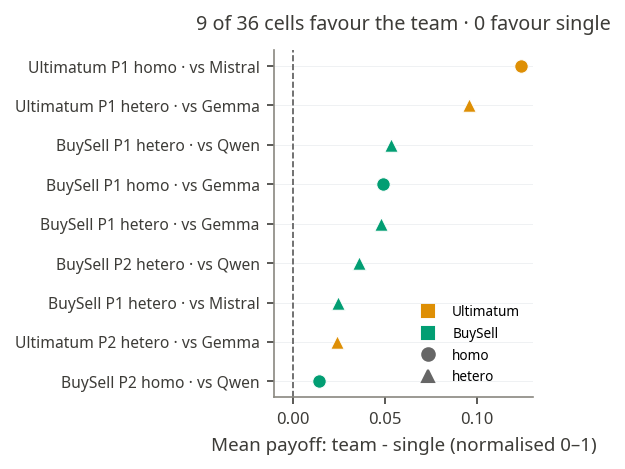

BuySell seller (P1): team-minus-single surplus, with absolute pooled means:
composition  team_mean  single_mean  delta   lo   hi  team_n  single_n
       homo       2.50         1.55   0.95 -1.4 3.30      76        84
     hetero       7.14         3.11   4.03  2.5 5.61      80       264

The nine CI-separated payoff cells (raw and span-normalised team - single):
     game seat variant  opponent  pay_diff  pay_lo  pay_hi    nd   nlo   nhi
ultimatum   P1    homo ministral    12.393   0.429  25.144 0.124 0.004 0.251
ultimatum   P1  hetero     gemma     9.567   0.621  17.934 0.096 0.006 0.179
  buysell   P1  hetero      qwen     5.356   2.521   8.120 0.054 0.025 0.081
  buysell   P1    homo     gemma     4.900   1.233   8.833 0.049 0.012 0.088
  buysell   P1  hetero     gemma     4.778   2.022   7.689 0.048 0.020 0.077
  buysell   P2  hetero      qwen     3.608   1.572   5.392 0.036 0.016 0.054
  buysell   P1  hetero ministral     2.453   0.166   4.673 0.025 0.002 0.047
ultimatum   P2  he

In [ ]:
# Proposer-seat surplus, shown as two figures.
# Fig A -- BuySell seller (P1) team-minus-single surplus per composition: each team cell is
# pooled against its matched single agents and the mean difference is bootstrapped, so one
# bar = the deliberation effect (absolute levels are in the table).
# Fig B -- the nine (game, seat, composition, opponent) cells whose team-minus-single payoff
# bootstrap CI clears zero, on the span-normalised [0,1] scale so the three games are
# comparable (BuySell and Ultimatum happen to share a span of 100, so their ordering is the
# same as in raw units -- the Ultimatum lead is not a scale artifact). Significance is
# invariant under the positive per-game rescaling, so the selection is unchanged: none
# favour the single agent and every cell sits in a proposing seat of BuySell or Ultimatum.
from matplotlib.lines import Line2D

def _pooled(game, seat, variant):
    tt = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == variant) & TEAM.valid]
    team = tt["focal_payoff"].values
    singles = [matched_single(game, seat, variant, opp).pipe(lambda b: b.loc[b.valid, "focal_payoff"].values)
               for opp in sorted(tt["opponent"].unique())]
    single = np.concatenate(singles) if singles else np.array([])
    return team, single

def _mean(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    return (float(x.mean()), len(x)) if len(x) else (np.nan, 0)

# --- Fig A: BuySell seller (P1) team-minus-single surplus, one bar per composition ---
figA, axL = plt.subplots(figsize=(HALF_WIDTH, 3.0))
DGROUPS = [("homo", "homogeneous\nteam", COL_HOMO), ("hetero", "heterogeneous\nteam", COL_HETERO)]
prop_rows = []
for i, (variant, lab, col) in enumerate(DGROUPS):
    team, single = _pooled("buysell", "P1", variant)
    diff, lo, hi = mean_diff_ci(pd.Series(team), pd.Series(single))
    tm, tn = _mean(team); sm, sn = _mean(single)
    prop_rows.append(dict(composition=variant, team_mean=tm, single_mean=sm,
                          delta=diff, lo=lo, hi=hi, team_n=tn, single_n=sn))
    yerr = None if not np.isfinite(lo) else [[diff - lo], [hi - diff]]
    axL.bar(i, diff, 0.6, color=col, edgecolor="white", linewidth=0.5,
            yerr=yerr, capsize=3, ecolor="0.4")
axL.axhline(0, color="0.35", lw=0.8, ls="--")
axL.set_xticks(range(2), [g[1] for g in DGROUPS], fontsize=8)
axL.set_xlim(-0.7, 1.7)
axL.set_ylabel("Seller surplus: team - single (ZUP)")
axL.set_title("BuySell — team as seller (P1)", fontsize=9.5)
figA.tight_layout()
save_plot(figA, "buysell_seller_surplus")
plt.show()

# --- Fig B: forest of the 9 CI-separated winner cells, span-normalised payoff ---
def _norm_diff(game, seat, variant, opp):
    ts = TEAM[(TEAM.game == game) & (TEAM.seat == seat) & (TEAM.variant == variant)
              & (TEAM.opponent == opp) & TEAM.valid]
    bs = matched_single(game, seat, variant, opp); bs = bs[bs.valid]
    tnorm = ts["focal_payoff"].map(lambda p: norm_payoff(game, p))
    snorm = bs["focal_payoff"].map(lambda p: norm_payoff(game, p))
    return mean_diff_ci(tnorm, snorm)

VAR_MARKER = {"homo": "o", "hetero": "^"}
sig = CMP[CMP.pay_rel == "team>single"].copy()
sig[["nd", "nlo", "nhi"]] = sig.apply(
    lambda r: pd.Series(_norm_diff(r.game, r.seat, r.variant, r.opponent)), axis=1)
sig = sig.sort_values("nd").reset_index(drop=True)
labels = [f"{GAME_LABEL[r.game]} {r.seat} {r.variant} · vs {FAM_LABEL[r.opponent]}" for r in sig.itertuples()]
figB, axR = plt.subplots(figsize=(FULL_WIDTH * 0.62, 3.2))
for i, r in enumerate(sig.itertuples()):
    axR.scatter(r.nd, i, s=42, marker=VAR_MARKER[r.variant], color=GAME_COLORS[r.game],
                edgecolor="white", linewidth=0.5, zorder=2)
axR.axvline(0, ls="--", color="0.35", lw=0.8)
axR.set_yticks(range(len(sig)), labels, fontsize=7.5)
axR.set_xlabel("Mean payoff: team - single (normalised 0–1)")
axR.set_title("9 of 36 cells favour the team · 0 favour single", fontsize=9.5)
axR.set_xlim(left=-0.01)
leg = [Line2D([], [], marker="s", ls="", color=GAME_COLORS[g], label=GAME_LABEL[g]) for g in ("ultimatum", "buysell")]
leg += [Line2D([], [], marker=VAR_MARKER[v], ls="", color="0.4", label=v) for v in ("homo", "hetero")]
axR.legend(handles=leg, fontsize=6.5, loc="lower right", ncols=1)
figB.tight_layout()
save_plot(figB, "ci_separated_payoff_cells")
plt.show()

print("BuySell seller (P1): team-minus-single surplus, with absolute pooled means:")
print(pd.DataFrame(prop_rows).round(2).to_string(index=False))
print("\nThe nine CI-separated payoff cells (raw and span-normalised team - single):")
print(sig.sort_values("nd", ascending=False)[
    ["game", "seat", "variant", "opponent", "pay_diff", "pay_lo", "pay_hi", "nd", "nlo", "nhi"]
].round(3).to_string(index=False))

The heterogeneous trio as **BuySell seller** is the single strongest cell — pooled surplus +7.1 ZUP against +3.1 for the matched
single agents, with a CI-separated payoff advantage against every opponent family. All nine
CI-separated cells sit in a **proposing seat** of BuySell or Ultimatum (the largest being the
homogeneous Ministral team keeping 94.6/100 as Ultimatum proposer, +12.4 over single
Ministral), and not one cell favours the single agent. The direction matches the Section-4
mechanism: when a member revises, it raises its own claim more often than it lowers it, so
deliberation acts as a one-way ratchet on the offer — which only pays off in the seat that
sets the price. In Trading, where neither side posts a take-it-or-leave-it price, the effect
vanishes.

### 2. Does heterogeneity matter?

Holding the opponent and seat fixed isolates composition: a homogeneous team and the
heterogeneous trio face the same single agent in the same seat. Each point is one of the
18 such cells.

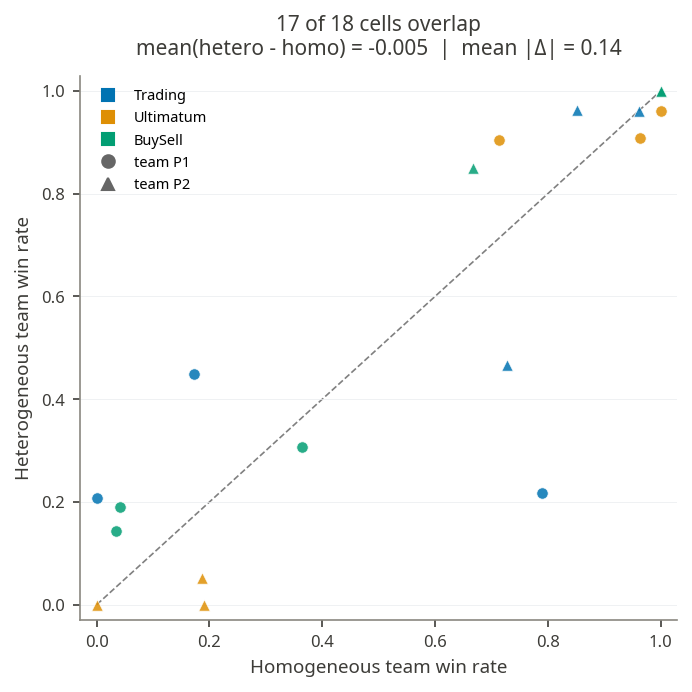

Homogeneous vs heterogeneous win-rate cells:
     game seat  opponent  homo_wr  hetero_wr         rel
  trading   P1     gemma    0.172      0.448     overlap
  trading   P1      qwen    0.789      0.217 homo>hetero
  trading   P1 ministral    0.000      0.208     overlap
  trading   P2     gemma    0.852      0.963     overlap
  trading   P2      qwen    0.727      0.467     overlap
  trading   P2 ministral    0.962      0.960     overlap
ultimatum   P1     gemma    1.000      0.962     overlap
ultimatum   P1      qwen    0.714      0.905     overlap
ultimatum   P1 ministral    0.964      0.909     overlap
ultimatum   P2     gemma    0.000      0.000     overlap
ultimatum   P2      qwen    0.188      0.053     overlap
ultimatum   P2 ministral    0.190      0.000     overlap
  buysell   P1     gemma    0.034      0.143     overlap
  buysell   P1      qwen    0.042      0.190     overlap
  buysell   P1 ministral    0.364      0.308     overlap
  buysell   P2     gemma    1.000      1.00

In [11]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH * 1.5, HALF_WIDTH * 1.5))
ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
for _, r in HH.iterrows():
    ax.scatter(r.homo_wr, r.hetero_wr, s=30, color=GAME_COLORS[r.game],
               marker="o" if r.seat == "P1" else "^", alpha=0.85, edgecolor="white", linewidth=0.4)
leg_seat = [Line2D([], [], marker="o", ls="", color="0.4", label="team P1"),
            Line2D([], [], marker="^", ls="", color="0.4", label="team P2")]
ax.legend(handles=leg_game + leg_seat, loc="upper left", fontsize=7)
ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Homogeneous team win rate"); ax.set_ylabel("Heterogeneous team win rate")
n_ov = (HH.rel == "overlap").sum()
hh_delta = HH.hetero_wr - HH.homo_wr
ax.set_title(f"{n_ov} of {len(HH)} cells overlap\n"
             f"mean(hetero - homo) = {hh_delta.mean():+.3f}  |  mean |Δ| = {hh_delta.abs().mean():.2f}",
             fontsize=10)
save_plot(fig, "homo_vs_hetero_winrate")
plt.show()
print("Homogeneous vs heterogeneous win-rate cells:")
print(HH[["game", "seat", "opponent", "homo_wr", "hetero_wr", "rel"]].round(3).to_string(index=False))
print(f"\nmean(hetero - homo) = {hh_delta.mean():+.3f}; median = {hh_delta.median():+.3f}; mean |Δ| = {hh_delta.abs().mean():.3f}")

The compositions are interchangeable: 17 of 18 cells have overlapping intervals
and the average heterogeneous-minus-homogeneous win rate is ≈0 (mean -0.005). That
near-zero average is genuine cancellation rather than uniformly small cells: individual
differences are sizable (mean |Δ|≈0.14, ranging from -0.57 to +0.28) but scatter
symmetrically about the diagonal with no net direction. The single exception is
Trading as P1 against Qwen, where the homogeneous (all-Qwen) team scores higher — but
that cell is exactly the confound to be wary of: the homogeneous team *is* the opponent
model, so a high score there reflects Qwen's strength on both sides, not an effect of
homogeneity. Once opponent and seat are held fixed, mixing model families changes
nothing measurable in the outcome.

### 3. Behaviour across model families

The previous sections pooled over which models a team is built from. That hides a
distinct question the design invites: is a *team* the same object regardless of family?
Two views answer it: who authors the heterogeneous team's chosen moves, and whether each
voter family is independently selecting the same author. The author view reads the Borda
winner of each heterogeneous turn back to the family that wrote it; the voter view reads
each member's first-place ranking directly.


650 committed heterogeneous moves over 650 turns
           win_share  ranked_first
family                            
gemma          0.174         0.152
qwen           0.022         0.048
ministral      0.805         0.800


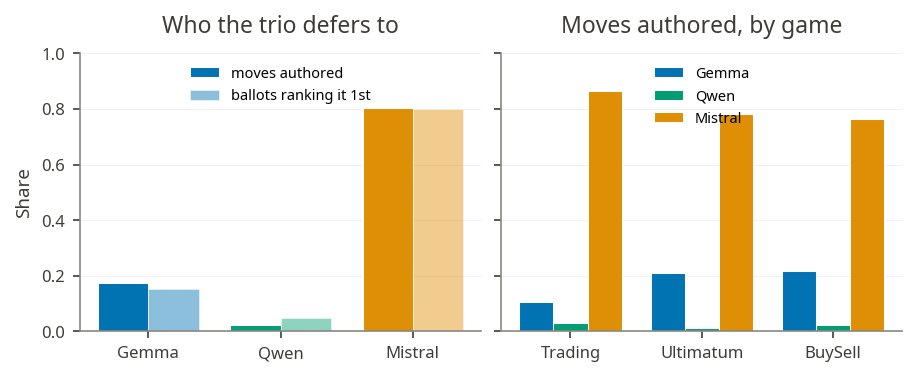

Heterogeneous-team consensus shares by family:
           win_share  ranked_first
family                            
gemma          0.174         0.152
qwen           0.022         0.048
ministral      0.805         0.800

Moves authored by game and family:
family     gemma   qwen  ministral
game                              
trading    0.106  0.030      0.864
ultimatum  0.209  0.011      0.780
buysell    0.216  0.022      0.763


In [12]:
# Heterogeneous teams: attribute each committed move to the family that authored it.
# winner_index -> slate[i] -> member i -> member_specs[i] (members are built in spec order).
def _member_families(gs_path):
    d = json.load(open(gs_path))
    tl = [i for i, pl in enumerate(d["players"]) if pl.get("class") == "NegotiationTeamAgent"]
    if not tl:
        return None, None
    team = d["players"][tl[0]]
    fams = [model_family(clean_name(s.get("id", ""))) for s in team.get("member_specs", [])]
    opp = d["players"][1 - tl[0]]
    return fams, model_family(clean_name(opp.get("model_id", opp.get("model", ""))))


vote = []
for seat, suffix in (("P1", ""), ("P2", "_p2")):
    for game in GAMES:
        root = os.path.join(LOGS_ROOT, "negotiation_team",
                            f"{game}_negotiation_team_hetero_v1{suffix}", SIZE)
        for gs in _states(root):
            fams, opp = _member_families(gs)
            if not fams:
                continue
            for tp in glob.glob(os.path.join(os.path.dirname(gs), "deliberation_trace_*.json")):
                tr = json.load(open(tp))
                rk = [r for r in tr.get("rankings", []) if r]
                wi = tr.get("winner_index")
                if not rk or wi is None or wi >= len(fams):
                    continue
                for j, fj in enumerate(fams):
                    vote.append(dict(game=game, family=fj, won=(j == wi),
                                     ranked_first=float(np.mean([r[0] == j for r in rk]))))
VOTE = pd.DataFrame(vote)
share = (VOTE.groupby("family").agg(win_share=("won", "mean"),
                                    ranked_first=("ranked_first", "mean")).reindex(FAMILIES))
print(f"{int(VOTE['won'].sum())} committed heterogeneous moves over {len(VOTE) // 3} turns")
print(share.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 2.4), sharey=True)
xa = np.arange(len(FAMILIES)); w = 0.38
axes[0].bar(xa - w / 2, share["win_share"], w, color=[FAM_COLORS[f] for f in FAMILIES],
            edgecolor="white", linewidth=0.5, label="moves authored")
axes[0].bar(xa + w / 2, share["ranked_first"], w, color=[FAM_COLORS[f] for f in FAMILIES],
            alpha=0.45, edgecolor="white", linewidth=0.5, label="ballots ranking it 1st")
axes[0].set_xticks(xa, [FAM_LABEL[f] for f in FAMILIES]); axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Share"); axes[0].set_title("Who the trio defers to")
axes[0].legend(fontsize=7, loc="upper center")
xb = np.arange(len(GAMES)); w2 = 0.26
for i, f in enumerate(FAMILIES):
    vals = [VOTE[VOTE.game == g].groupby("family")["won"].mean().get(f, 0.0) for g in GAMES]
    axes[1].bar(xb + (i - 1) * w2, vals, w2, color=FAM_COLORS[f], label=FAM_LABEL[f],
                edgecolor="white", linewidth=0.5)
axes[1].set_xticks(xb, [GAME_LABEL[g] for g in GAMES]); axes[1].set_title("Moves authored, by game")
axes[1].legend(fontsize=7, loc="upper center")
save_plot(fig, "hetero_family_consensus")
plt.show()
print("Heterogeneous-team consensus shares by family:")
print(share.round(3).to_string())
print("\nMoves authored by game and family:")
print((VOTE.groupby(["game", "family"])["won"].mean().unstack("family").reindex(index=GAMES, columns=FAMILIES).round(3).to_string()))


First-place rankings by voter family are informative because they show whether the heterogeneous team is aggregating distinct preferences or whether every member family is selecting the same member's proposal.


1950 first-place ballots from heterogeneous teams
top        gemma   qwen  ministral
voter                             
gemma      0.251  0.052      0.697
qwen       0.142  0.023      0.835
ministral  0.063  0.069      0.868


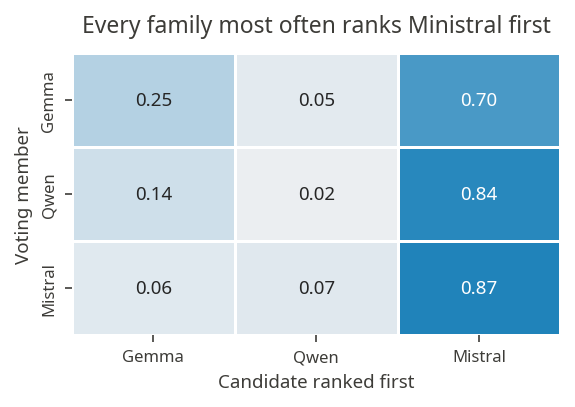

Voter-to-top-choice preference matrix shown in the heatmap:
top        gemma   qwen  ministral
voter                             
gemma      0.251  0.052      0.697
qwen       0.142  0.023      0.835
ministral  0.063  0.069      0.868

Top choice per voter family:
voter
gemma        Mistral
qwen         Mistral
ministral    Mistral


In [13]:
voter_rows = []
for seat, suffix in (("P1", ""), ("P2", "_p2")):
    for game in GAMES:
        root = os.path.join(LOGS_ROOT, "negotiation_team",
                            f"{game}_negotiation_team_hetero_v1{suffix}", SIZE)
        for gs in _states(root):
            fams, opp = _member_families(gs)
            if not fams:
                continue
            for tp in glob.glob(os.path.join(os.path.dirname(gs), "deliberation_trace_*.json")):
                tr = json.load(open(tp))
                for voter_idx, ranking in enumerate([r for r in tr.get("rankings", []) if r]):
                    if voter_idx >= len(fams) or not ranking or ranking[0] >= len(fams):
                        continue
                    voter_rows.append(dict(game=game, seat=seat, voter=fams[voter_idx], top=fams[ranking[0]]))
VOTER_PREFS = pd.DataFrame(voter_rows)
voter_matrix = (pd.crosstab(VOTER_PREFS.voter, VOTER_PREFS.top, normalize="index")
                .reindex(index=FAMILIES, columns=FAMILIES).fillna(0))
print(f"{len(VOTER_PREFS)} first-place ballots from heterogeneous teams")
print(voter_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.62, 2.6))
cmap = sns.light_palette("#0173b2", as_cmap=True)
sns.heatmap(voter_matrix, annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1, cbar=False,
            linewidths=0.5, linecolor="white", ax=ax,
            xticklabels=[FAM_LABEL[f] for f in FAMILIES],
            yticklabels=[FAM_LABEL[f] for f in FAMILIES])
ax.set_xlabel("Candidate ranked first")
ax.set_ylabel("Voting member")
ax.set_title("Every family most often ranks Ministral first")
save_plot(fig, "hetero_voter_preferences")
plt.show()
print("Voter-to-top-choice preference matrix shown in the heatmap:")
print(voter_matrix.round(3).to_string())
print("\nTop choice per voter family:")
print(voter_matrix.idxmax(axis=1).map(FAM_LABEL).to_string())


Across the 650 committed heterogeneous moves, the Ministral member's draft wins the Borda vote 0.805 of the time
and receives 0.800 of first-place rankings.Gemma voters rank Ministral first 0.697 of the time,
Qwen voters 0.835, and Ministral voters 0.868. Gemma supplies 0.174 of chosen moves and
Qwen only 0.022, even though Qwen is the strongest single negotiator in the cross-play
benchmark. 


### 4. What the discussion rounds do

The team takes two discussion rounds between the independent drafts and the vote — does
the proposal actually change across them? For each member at each stage (initial draft,
after round 1, after round 2) its move is reduced to a *proposal signature*: the
`<player answer>` action plus the normalised `<newly proposed trade>` offer, ignoring
the surrounding reasoning. That separates changes to the offer itself from changes to
its justification, and lets us watch the three members move relative to one another.

Per-member offer-change rate (substantive proposal, not reasoning):
         draft_to_r1  r1_to_r2
variant                       
hetero         0.567     0.397
homo           0.438     0.323

Share of turns all 3 propose the same offer (draft / after r1 / after r2):
         draft     r1     r2
variant                     
hetero   0.197  0.483  0.594
homo     0.403  0.588  0.652

Members holding the winning offer (of 3) and how often the winner moved its own offer:
         at_draft  at_final  winner_moved
variant                                  
hetero      1.571     2.378         0.252
homo        1.928     2.539         0.282


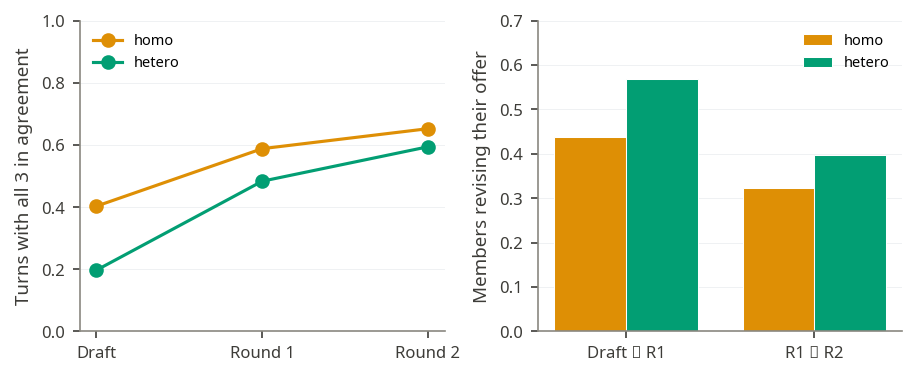

Agreement trajectory shown in the line plot:
         draft     r1     r2
variant                     
hetero   0.197  0.483  0.594
homo     0.403  0.588  0.652

Offer-revision rates shown in the bar plot:
         draft_to_r1  r1_to_r2
variant                       
hetero         0.567     0.397
homo           0.438     0.323


In [14]:
import re


def _sig(text):
    # Proposal signature: the action + the normalised offer, ignoring the reasoning prose.
    a = re.search(r"<player answer>\s*(.*?)\s*</player answer>", text, re.S)
    tr = re.search(r"<newly proposed trade>\s*(.*?)\s*</newly proposed trade>", text, re.S)
    act = a.group(1).strip().upper() if a else "?"
    trade = re.sub(r"\s+", " ", tr.group(1)).strip().upper() if tr else ""
    if act in ("ACCEPT", "REJECT"):
        trade = ""  # action-only move carries no trade
    return (act, trade)


prop, agree = [], []
for variant in ("homo", "hetero"):
    for game in GAMES:
        for suffix in ("", "_p2"):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for tp in glob.glob(os.path.join(root, "**", "deliberation_trace_*.json"), recursive=True):
                t = json.load(open(tp))
                dr, rounds = t.get("drafts") or [], t.get("discussion_rounds") or []
                if len(dr) != 3 or len(rounds) != 2 or any(len(r) != 3 for r in rounds):
                    continue
                # three stages: draft, after round 1, after round 2
                stages = [[_sig(x) for x in dr], [_sig(x) for x in rounds[0]], [_sig(x) for x in rounds[1]]]
                wi = t.get("winner_index")
                for m in range(3):                       # did each member's offer move?
                    prop.append(dict(variant=variant, t1=stages[0][m] != stages[1][m],
                                     t2=stages[1][m] != stages[2][m]))
                wsig = stages[2][wi] if (wi is not None and wi < 3) else None
                agree.append(dict(variant=variant,
                                  draft=len(set(stages[0])) == 1,   # all 3 propose the same offer?
                                  r1=len(set(stages[1])) == 1,
                                  r2=len(set(stages[2])) == 1,
                                  match_draft=(sum(s == wsig for s in stages[0]) if wsig else np.nan),
                                  match_final=(sum(s == wsig for s in stages[2]) if wsig else np.nan),
                                  winner_moved=(stages[0][wi] != stages[2][wi]) if wsig else np.nan))
PROP = pd.DataFrame(prop); AGREE = pd.DataFrame(agree)
print("Per-member offer-change rate (substantive proposal, not reasoning):")
print(PROP.groupby("variant").agg(draft_to_r1=("t1", "mean"), r1_to_r2=("t2", "mean")).round(3))
print("\nShare of turns all 3 propose the same offer (draft / after r1 / after r2):")
print(AGREE.groupby("variant").agg(draft=("draft", "mean"), r1=("r1", "mean"), r2=("r2", "mean")).round(3))
print("\nMembers holding the winning offer (of 3) and how often the winner moved its own offer:")
print(AGREE.groupby("variant").agg(at_draft=("match_draft", "mean"), at_final=("match_final", "mean"),
                                   winner_moved=("winner_moved", "mean")).round(3))

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 2.4))
# left: convergence trajectory (front-loaded into round 1)
xs = [0, 1, 2]
for variant, col in (("homo", COL_HOMO), ("hetero", COL_HETERO)):
    g = AGREE[AGREE.variant == variant]
    axes[0].plot(xs, [g["draft"].mean(), g["r1"].mean(), g["r2"].mean()],
                 marker="o", color=col, label=variant)
axes[0].set_xticks(xs, ["Draft", "Round 1", "Round 2"])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Turns with all 3 in agreement")
axes[0].legend(fontsize=7, loc="upper left")
# right: how often members revise their offer, per round
xb = np.arange(2); w = 0.38
for i, (variant, col) in enumerate((("homo", COL_HOMO), ("hetero", COL_HETERO))):
    g = PROP[PROP.variant == variant]
    axes[1].bar(xb + (i - 0.5) * w, [g["t1"].mean(), g["t2"].mean()], w, color=col,
                label=variant, edgecolor="white", linewidth=0.5)
axes[1].set_xticks(xb, ["Draft → R1", "R1 → R2"]); axes[1].set_ylim(0, 0.7)
axes[1].set_ylabel("Members revising their offer")
axes[1].legend(fontsize=7, loc="upper right")
save_plot(fig, "discussion_dynamics")
plt.show()
agree_summary = AGREE.groupby("variant").agg(draft=("draft", "mean"), r1=("r1", "mean"), r2=("r2", "mean")).round(3)
prop_summary = PROP.groupby("variant").agg(draft_to_r1=("t1", "mean"), r1_to_r2=("t2", "mean")).round(3)
print("Agreement trajectory shown in the line plot:")
print(agree_summary.to_string())
print("\nOffer-revision rates shown in the bar plot:")
print(prop_summary.to_string())

Members rewrite their actual offer on 57% of first-round revisions in mixed teams and
44% in homogeneous ones, with the second round revising less (40% and 32%). The effect is agreement: heterogeneous teams
begin far apart, all three proposing the same offer on only 20% of turns, but that rises
to 48% after one round and 59% after the second, near the homogeneous level
(40%→59%→65%). The number of members holding the eventually-chosen offer climbs from ~1.6 to ~2.4 of three while the winning member
changes its own offer only ~25% of the time. 

The rounds change offers, but in which direction? Reducing each proposal to the amount the proposing team \textbf{claims for itself} (the seller's $\text{price}-40$, the buyer's $60-\text{price}$, the proposer's $100-\text{offer}$, the responder's demanded share, and in Trading the net units received) turns every offer into one number on a common ``self-favorability'' scale. That lets us ask whether revisions concede or harden, and whether the vote settles on a compromise or on one member's extreme.

Signed change in self-claim when a member revises (+ = more aggressive):
           mean  median  pct_up    n
game                                
buysell    5.30     5.0    0.73  288
trading    0.21     2.0    0.54  386
ultimatum  1.70     5.0    0.54  224

Where the agreed move lands among 581 contested turns (drafts disagree):
pos        most aggressive  middle  most generous
game                                             
trading              0.405   0.179          0.417
ultimatum            0.534   0.062          0.404
buysell              0.634   0.235          0.131
overall: {'most aggressive': 0.509, 'most generous': 0.324, 'middle': 0.167}


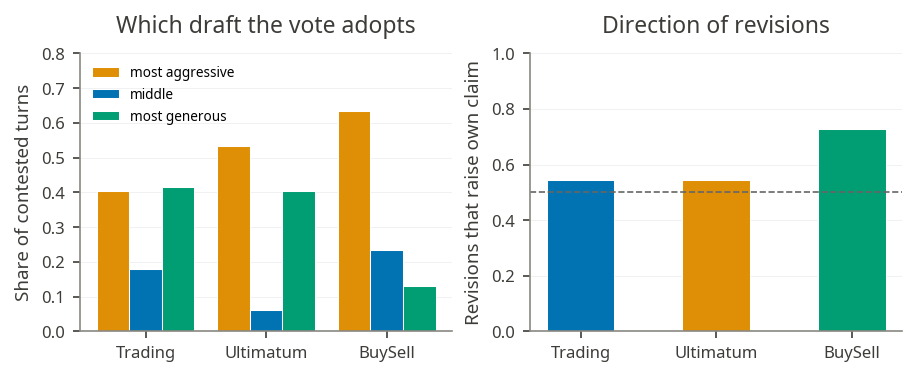

Agreed-draft position shares shown in the left bar chart:
pos        most aggressive  middle  most generous
game                                             
trading              0.405   0.179          0.417
ultimatum            0.534   0.062          0.404
buysell              0.634   0.235          0.131

Share of revisions that raise own claim (right bar chart):
Trading      0.544
Ultimatum    0.545
BuySell      0.729


In [15]:
def parse_claim(text, game, seat):
    # Self-claim of a proposal: how much the proposing team asks for itself, common scale.
    m = re.search(r"<newly proposed trade>\s*(.*?)\s*</newly proposed trade>", text, re.S)
    if not m:
        return None
    s = re.sub(r"\s+", " ", m.group(1))
    if "GIVES" not in s.upper():
        return None
    if game == "buysell":
        pz = re.search(r"ZUP:\s*([-+]?\d+\.?\d*)", s, re.I)
        if not pz:
            return None
        price = float(pz.group(1))
        return (price - 40.0) if seat == "P1" else (60.0 - price)   # seller surplus / buyer surplus
    if game == "ultimatum":
        rd = re.search(r"RED Gives Dollars:\s*([-+]?\d+\.?\d*)", s, re.I)
        if not rd:
            return None
        offer = float(rd.group(1))                                  # dollars RED hands the responder
        return (100.0 - offer) if seat == "P1" else offer
    red = re.search(r"RED Gives(.*?)(?:\| *Player BLUE|$)", s, re.I)
    blue = re.search(r"BLUE Gives(.*)", s, re.I)
    if not red or not blue:
        return None
    nums = lambda x: [float(n) for n in re.findall(r"[-+]?\d+\.?\d*", x)]
    rv, bv = sum(nums(red.group(1))), sum(nums(blue.group(1)))
    return (bv - rv) if seat == "P1" else (rv - bv)                 # net units the team receives


DELTA, LAND = [], []
for variant in ("homo", "hetero"):
    for game in GAMES:
        for suffix, seat in (("", "P1"), ("_p2", "P2")):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for tp in glob.glob(os.path.join(root, "**", "deliberation_trace_*.json"), recursive=True):
                t = json.load(open(tp))
                dr, rounds = t.get("drafts") or [], t.get("discussion_rounds") or []
                if len(dr) != 3 or len(rounds) != 2 or any(len(r) != 3 for r in rounds):
                    continue
                wi = t.get("winner_index")
                cd = [parse_claim(x, game, seat) for x in dr]
                cf = [parse_claim(x, game, seat) for x in rounds[1]]
                for m in range(3):                                  # signed move when a member revises
                    if cd[m] is not None and cf[m] is not None and cd[m] != cf[m]:
                        DELTA.append(dict(game=game, delta=cf[m] - cd[m]))
                valid = [c for c in cd if c is not None]             # where the vote lands vs the drafts
                if wi is None or wi >= 3 or cf[wi] is None or len(valid) < 2:
                    continue
                mx, mn = max(valid), min(valid)
                if mx - mn < 1e-6:                                   # members already agreed: nothing to pick
                    continue
                w = cf[wi]
                LAND.append(dict(game=game,
                                 pos="most aggressive" if w >= mx - 1e-6 else
                                     "most generous" if w <= mn + 1e-6 else "middle"))
DELTA, LAND = pd.DataFrame(DELTA), pd.DataFrame(LAND)
d = DELTA.groupby("game")["delta"]
print("Signed change in self-claim when a member revises (+ = more aggressive):")
print(pd.DataFrame({"mean": d.mean(), "median": d.median(),
                    "pct_up": d.apply(lambda s: (s > 0).mean()), "n": d.size()}).round(2).to_string())
ct = (pd.crosstab(LAND.game, LAND.pos, normalize="index")
      .reindex(index=GAMES, columns=["most aggressive", "middle", "most generous"]).fillna(0))
print(f"\nWhere the agreed move lands among {len(LAND)} contested turns (drafts disagree):")
print(ct.round(3).to_string())
print("overall:", {k: round(v, 3) for k, v in LAND['pos'].value_counts(normalize=True).items()})

POSCOL = {"most aggressive": "#de8f05", "middle": "#0173b2", "most generous": "#029e73"}
fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 2.4))
xa = np.arange(len(GAMES)); w = 0.27
for i, pos in enumerate(["most aggressive", "middle", "most generous"]):
    axes[0].bar(xa + (i - 1) * w, [ct.loc[g, pos] for g in GAMES], w, color=POSCOL[pos],
                label=pos, edgecolor="white", linewidth=0.5)
axes[0].set_xticks(xa, [GAME_LABEL[g] for g in GAMES]); axes[0].set_ylim(0, 0.8)
axes[0].set_ylabel("Share of contested turns"); axes[0].set_title("Which draft the vote adopts")
axes[0].legend(fontsize=6.5, loc="upper left")
pct = [(DELTA[DELTA.game == g]["delta"] > 0).mean() for g in GAMES]
axes[1].bar(xa, pct, 0.5, color=[GAME_COLORS[g] for g in GAMES], edgecolor="white", linewidth=0.5)
axes[1].axhline(0.5, ls="--", color="0.4", lw=0.8)
axes[1].set_xticks(xa, [GAME_LABEL[g] for g in GAMES]); axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Revisions that raise own claim"); axes[1].set_title("Direction of revisions")
save_plot(fig, "proposal_direction")
plt.show()
print("Agreed-draft position shares shown in the left bar chart:")
print(ct.round(3).to_string())
print("\nShare of revisions that raise own claim (right bar chart):")
print(pd.Series(dict(zip([GAME_LABEL[g] for g in GAMES], np.round(pct, 3)))).to_string())

When a member revises its offer it raises its own claim more often than it lowers it — clearly in
BuySell, where 73% of revisions move up and the seller's ask climbs about six ZUP on
average, and weakly in Ultimatum and Trading. 

### 5. Relationship between draft diversity and outcome

We measure within-turn draft diversity as the mean pairwise cosine *distance* (1 − cosine) between the three drafts'
TF-IDF vectors a text-surface measure.
We then ask whether more diverse drafts produce better team outcomes — where the
*outcome* is the team's own payoff for the run, rescaled to each game's
[0, 1] span so the three games are comparable.

1288 turns; homo vs hetero mean draft diversity:
         diversity  sig_distinct
variant                         
hetero       0.499         2.252
homo         0.358         1.845

per-run diversity vs normalised team payoff: n=1006  Spearman=-0.052 (p=0.10)
per-run diversity vs team win rate:          n=806   Spearman=-0.090 (p=0.01)


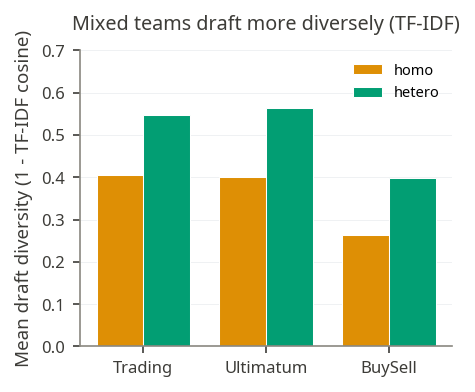

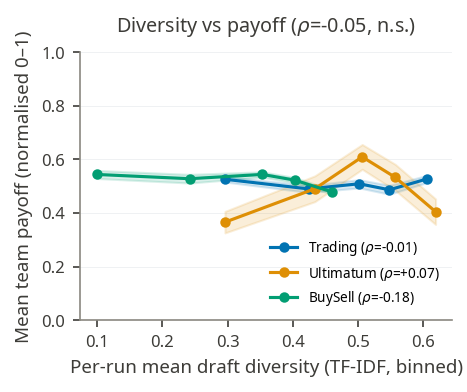

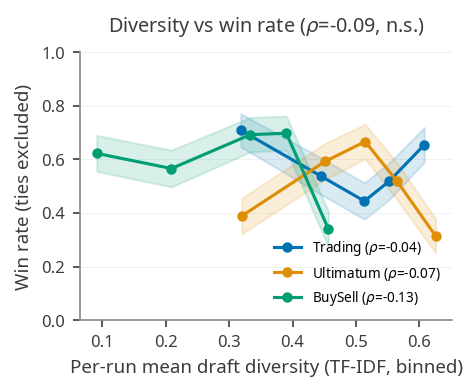

Draft-diversity means shown in the bar chart:
                   diversity  sig_distinct
variant game                              
hetero  buysell        0.397         2.228
        trading        0.548         2.445
        ultimatum      0.564         2.033
homo    buysell        0.264         1.684
        trading        0.406         2.197
        ultimatum      0.400         1.562

Per-game diversity/payoff correlations:
     game   n    rho
  Trading 330 -0.014
Ultimatum 349  0.072
  BuySell 327 -0.183

Per-game diversity/win-rate correlations:
     game   n    rho
  Trading 272 -0.044
Ultimatum 270 -0.071
  BuySell 264 -0.134


In [16]:
# Within-turn draft diversity (TF-IDF cosine distance) and whether it buys outcomes.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

all_drafts, div_rows = [], []
for variant in ("homo", "hetero"):
    for seat, suffix in (("P1", ""), ("P2", "_p2")):
        for game in GAMES:
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for tp in glob.glob(os.path.join(root, "**", "deliberation_trace_*.json"), recursive=True):
                tr = json.load(open(tp))
                dr = tr.get("drafts") or []
                if len(dr) != 3:
                    continue
                idx = list(range(len(all_drafts), len(all_drafts) + 3))
                all_drafts.extend(dr)
                div_rows.append(dict(variant=variant, game=game, seat=seat,
                                     rundir=os.path.dirname(tp), idx=idx,
                                     sig_distinct=len(set(_sig(x) for x in dr))))
TFM = TfidfVectorizer().fit_transform(all_drafts)
tri = np.triu_indices(3, k=1)
for r in div_rows:
    sim = cosine_similarity(TFM[r["idx"]])
    r["diversity"] = float(1 - sim[tri].mean())
DIV = pd.DataFrame(div_rows)

# Join per-run mean diversity to that run's team-seat payoff and win; store all completed
# runs so the win-rate panel has the same sample as the payoff panel (ties become NaN).
run_div = DIV.groupby("rundir")["diversity"].mean()
out_rows = []
for variant in ("homo", "hetero"):
    for seat, suffix in (("P1", ""), ("P2", "_p2")):
        for game in GAMES:
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1{suffix}", SIZE)
            for path in _states(root):
                rd = os.path.dirname(path)
                if rd not in run_div.index:
                    continue
                fp, op, valid, win = focal_view(seat, game, _load_run(path, game))
                out_rows.append(dict(game=game, diversity=run_div[rd],
                                     payoff=norm_payoff(game, fp) if valid else np.nan,
                                     win=win))
DOUT = pd.DataFrame(out_rows)

dout_pay = DOUT.dropna(subset=["payoff"])
dout_wr  = DOUT.dropna(subset=["win"])
rho,    pval    = spearmanr(dout_pay.diversity, dout_pay.payoff)
rho_wr, pval_wr = spearmanr(dout_wr.diversity,  dout_wr.win)

print(f"{len(DIV)} turns; homo vs hetero mean draft diversity:")
print(DIV.groupby("variant").agg(diversity=("diversity", "mean"),
      sig_distinct=("sig_distinct", "mean")).round(3).to_string())
print(f"\nper-run diversity vs normalised team payoff: n={len(dout_pay)}  Spearman={rho:+.3f} (p={pval:.2f})")
print(f"per-run diversity vs team win rate:          n={len(dout_wr)}   Spearman={rho_wr:+.3f} (p={pval_wr:.2f})")

# --- Plot 1: bar chart of mean draft diversity per game / composition ---
fig, ax = plt.subplots(figsize=(HALF_WIDTH, 2.5))
xa = np.arange(len(GAMES)); w = 0.38
for i, variant in enumerate(["homo", "hetero"]):
    vals = [DIV[(DIV.variant == variant) & (DIV.game == g)]["diversity"].mean() for g in GAMES]
    ax.bar(xa + (i - 0.5) * w, vals, w, label=variant,
           color=COL_HOMO if variant == "homo" else COL_HETERO, edgecolor="white", linewidth=0.5)
ax.set_xticks(xa, [GAME_LABEL[g] for g in GAMES]); ax.set_ylim(0, 0.7)
ax.set_ylabel("Mean draft diversity (1 - TF-IDF cosine)")
ax.set_title("Mixed teams draft more diversely (TF-IDF)", fontsize=9.5)
ax.legend(fontsize=7, loc="upper right")
save_plot(fig, "draft_diversity_bar")
plt.show()

# --- Plot 2: binned diversity vs normalised payoff ---
fig, ax = plt.subplots(figsize=(HALF_WIDTH, 2.5))
for g in GAMES:
    sub = dout_pay[dout_pay.game == g]
    b = pd.qcut(sub.diversity, 5, duplicates="drop")
    grp = sub.groupby(b, observed=True)
    x = grp.diversity.mean().values
    m = grp.payoff.mean().values
    se = grp.payoff.agg(lambda v: v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0).values
    rg, _ = spearmanr(sub.diversity, sub.payoff)
    ax.plot(x, m, marker="o", ms=4, color=GAME_COLORS[g], label=f"{GAME_LABEL[g]} ($\\rho$={rg:+.2f})")
    ax.fill_between(x, m - se, m + se, color=GAME_COLORS[g], alpha=0.15)
ax.set_ylim(0, 1)
ax.set_xlabel("Per-run mean draft diversity (TF-IDF, binned)")
ax.set_ylabel("Mean team payoff (normalised 0–1)")
ax.set_title(f"Diversity vs payoff ($\\rho$={rho:+.2f}, n.s.)", fontsize=9.5)
ax.legend(fontsize=6.5, loc="lower right")
save_plot(fig, "draft_diversity_payoff")
plt.show()

# --- Plot 3: binned diversity vs win rate (ties excluded) ---
fig, ax = plt.subplots(figsize=(HALF_WIDTH, 2.5))
for g in GAMES:
    sub = dout_wr[dout_wr.game == g]
    b = pd.qcut(sub.diversity, 5, duplicates="drop")
    grp = sub.groupby(b, observed=True)
    x = grp.diversity.mean().values
    m = grp.win.mean().values
    se = grp.win.agg(lambda v: v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0).values
    rg, _ = spearmanr(sub.diversity, sub.win)
    ax.plot(x, m, marker="o", ms=4, color=GAME_COLORS[g], label=f"{GAME_LABEL[g]} ($\\rho$={rg:+.2f})")
    ax.fill_between(x, m - se, m + se, color=GAME_COLORS[g], alpha=0.15)
ax.set_ylim(0, 1)
ax.set_xlabel("Per-run mean draft diversity (TF-IDF, binned)")
ax.set_ylabel("Win rate (ties excluded)")
ax.set_title(f"Diversity vs win rate ($\\rho$={rho_wr:+.2f}, n.s.)", fontsize=9.5)
ax.legend(fontsize=6.5, loc="lower right")
save_plot(fig, "draft_diversity_winrate")
plt.show()

print("Draft-diversity means shown in the bar chart:")
print(DIV.groupby(["variant", "game"]).agg(diversity=("diversity", "mean"), sig_distinct=("sig_distinct", "mean")).round(3).to_string())
print("\nPer-game diversity/payoff correlations:")
print(pd.DataFrame([
    dict(game=GAME_LABEL[g], n=len(dout_pay[dout_pay.game == g]),
         rho=spearmanr(dout_pay[dout_pay.game == g].diversity, dout_pay[dout_pay.game == g].payoff)[0])
    for g in GAMES
]).round(3).to_string(index=False))
print("\nPer-game diversity/win-rate correlations:")
print(pd.DataFrame([
    dict(game=GAME_LABEL[g], n=len(dout_wr[dout_wr.game == g]),
         rho=spearmanr(dout_wr[dout_wr.game == g].diversity, dout_wr[dout_wr.game == g].win)[0])
    for g in GAMES
]).round(3).to_string(index=False))

**Diversity doesn't improve outcomes.** Heterogeneous teams do draft more diversely than
homogeneous ones in every game (overall ≈0.50 vs ≈0.36 cosine distance, with more
distinct offer signatures too). Yet that diversity converts into neither payoff nor win
rate: across ≈1,000 valid runs the per-run mean draft diversity is uncorrelated with the
team's span-normalised payoff (Spearman ρ ≈ −0.05, n.s.) and equally uncorrelated with
the team's win rate (ρ ≈ −0.06, n.s.). The flat binned trends per game confirm the
null at every point in the diversity range.

### 6. Full results: per-cell team vs single deltas

The heatmaps below show every cell at once: the team-minus-single
**absolute** team level and the team-minus-single **change**, in both **win rate** and
**span-normalised payoff**, for each game (columns), seat and
opponent (rows), split by composition (panels). 

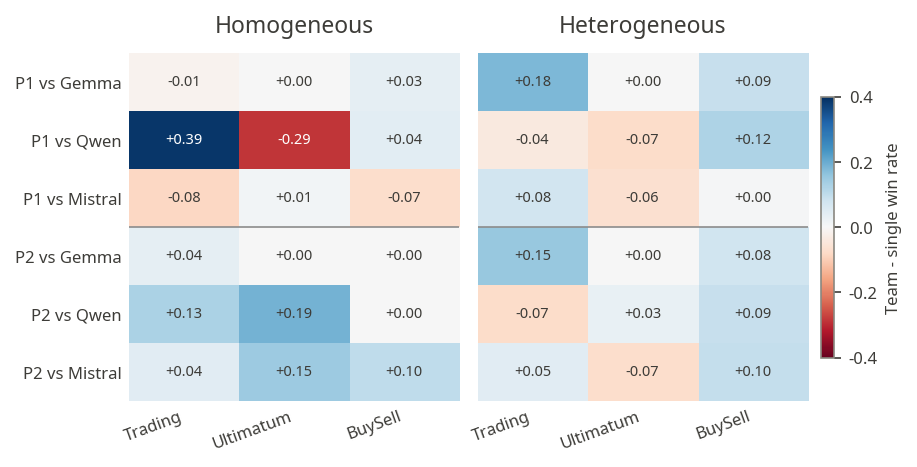

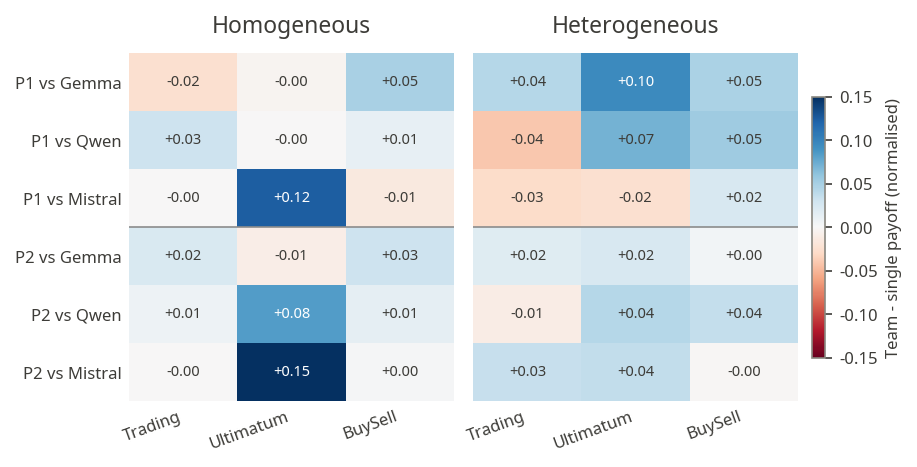

Win-rate delta (team - single):
game                   BuySell  Trading  Ultimatum
variant seat opponent                             
hetero  P1   Gemma        0.09     0.18       0.00
             Mistral      0.00     0.08      -0.06
             Qwen         0.12    -0.04      -0.07
        P2   Gemma        0.08     0.15       0.00
             Mistral      0.10     0.05      -0.07
             Qwen         0.09    -0.07       0.03
homo    P1   Gemma        0.03    -0.01       0.00
             Mistral     -0.07    -0.08       0.01
             Qwen         0.04     0.39      -0.29
        P2   Gemma        0.00     0.04       0.00
             Mistral      0.10     0.04       0.15
             Qwen         0.00     0.13       0.19

Normalised-payoff delta (team - single):
game                   BuySell  Trading  Ultimatum
variant seat opponent                             
hetero  P1   Gemma       0.048    0.042      0.096
             Mistral     0.025   -0.027     -0.024
        

In [17]:
# Per-cell team - single deltas as diverging heatmaps (annex full-results view).
# Rows = seat x opponent, columns = game, panels = composition; mirrors the persona heatmaps.
def _norm_pay_delta_cell(g, seat, variant, opp):
    ts = TEAM[(TEAM.game == g) & (TEAM.seat == seat) & (TEAM.variant == variant) & (TEAM.opponent == opp)]
    bs = matched_single(g, seat, variant, opp)
    tn = ts.loc[ts.valid, "focal_payoff"].map(lambda p: norm_payoff(g, p)).mean()
    sn = bs.loc[bs.valid, "focal_payoff"].map(lambda p: norm_payoff(g, p)).mean()
    return tn - sn

win_lu, pay_lu = {}, {}
for r in CMP.itertuples():
    win_lu[(r.game, r.seat, r.variant, r.opponent)] = r.team_wr - r.single_wr
    pay_lu[(r.game, r.seat, r.variant, r.opponent)] = _norm_pay_delta_cell(r.game, r.seat, r.variant, r.opponent)

row_keys = [(seat, opp) for seat in ("P1", "P2") for opp in FAMILIES]
row_labels = [f"{seat} vs {FAM_LABEL[opp]}" for (seat, opp) in row_keys]

def _mat(lu, variant):
    return np.array([[lu.get((g, seat, variant, opp), np.nan) for g in GAMES]
                     for (seat, opp) in row_keys], dtype=float)

def _heat(lu, V, cblabel, slug):
    fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.0), sharey=True)
    for ax, variant in zip(axes, ("homo", "hetero")):
        m = _mat(lu, variant)
        im = ax.imshow(np.ma.masked_invalid(m), cmap="RdBu", vmin=-V, vmax=V, aspect="auto")
        ax.set_xticks(range(len(GAMES)), [GAME_LABEL[g] for g in GAMES], rotation=20, ha="right")
        ax.set_yticks(range(len(row_keys)), row_labels)
        ax.grid(False); ax.spines[:].set_visible(False); ax.tick_params(length=0)
        ax.axhline(len(FAMILIES) - 0.5, color="0.55", lw=0.8)  # separate the P1 / P2 blocks
        ax.set_title("Homogeneous" if variant == "homo" else "Heterogeneous")
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                if np.isnan(m[i, j]):
                    continue
                ax.text(j, i, f"{m[i, j]:+.2f}", ha="center", va="center", fontsize=7,
                        color="white" if abs(m[i, j]) > 0.55 * V else "#3D3C38")
    cb = fig.colorbar(im, ax=axes, shrink=0.75, pad=0.02)
    cb.set_label(cblabel, fontsize=8)
    save_plot(fig, slug)
    plt.show()

_heat(win_lu, 0.4, "Team - single win rate", "team_delta_winrate_heatmap")
_heat(pay_lu, 0.15, "Team - single payoff (normalised)", "team_delta_payoff_heatmap")

# numbers behind the figures (annex tables)
WD = pd.DataFrame([dict(seat=s, opponent=FAM_LABEL[o], variant=v, game=GAME_LABEL[g],
                        win_delta=win_lu.get((g, s, v, o), np.nan),
                        pay_delta_norm=pay_lu.get((g, s, v, o), np.nan))
                   for (s, o) in row_keys for v in ("homo", "hetero") for g in GAMES])
print("Win-rate delta (team - single):")
print(WD.pivot_table(index=["variant", "seat", "opponent"], columns="game",
                     values="win_delta", observed=True).round(2).to_string())
print("\nNormalised-payoff delta (team - single):")
print(WD.pivot_table(index=["variant", "seat", "opponent"], columns="game",
                     values="pay_delta_norm", observed=True).round(3).to_string())